# How warm was Oklahoma City on 6 May 2024 compared with its hourly normals?

Compare one day's routine temperature reports at Will Rogers World Airport with
the airport's 1991–2020 hourly temperature normals. The calculation matches
each report to the nearest hourly normal, reports what was excluded or
unmatched, and then restores both pinned files into an empty cache. It
describes one station and one day, not statistical rarity or a climate trend.

This study needs `usdata[pandas]` and matplotlib. It downloads two small CSVs
and runs in a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:00:00+00:00
usdata 0.26.0; pandas 3.0.6


## Data

One manifest names two sources for the same airport, both in metric units:

- [Local Climatological Data](https://usdata.dev/datasets/noaa/lcd/) (LCD),
  named `observations`: every report filed on 6 May 2024 at station
  `72353013967`, of which the routine hourly readings are the observations.
- [Climate normals](https://usdata.dev/datasets/noaa/climate-normals/), named
  `normals`, with `period: hourly`: the 1991–2020 hourly mean temperature at
  station `USW00013967`. The request covers 6 and 7 May, because the day's
  last report matches the next midnight's normal.

In [2]:
print(manifest.read_text())

name: okc-hourly-anomalies
sources:
  - name: observations
    dataset: noaa:lcd
    start: 2024-05-06
    end: 2024-05-06
    variables: [HourlyDryBulbTemperature]
    params:
      stations: "72353013967"
      units: metric
  - name: normals
    dataset: noaa:climate-normals
    start: 2024-05-06
    end: 2024-05-07
    variables: [HLY-TEMP-NORMAL]
    params:
      stations: USW00013967
      period: hourly
      units: metric



In [3]:
result = pull(manifest)
observations = result.one("observations").open(dtype={"DATE": "string"})
normals = result.one("normals").open(dtype={"DATE": "string"})
print(f"Fetched {len(observations)} LCD reports and {len(normals)} hourly normals.")
print(f"Lockfile pins {len(result.lockfile.assets)} assets.")
print()
for item in result.fetched:
    print(item.asset.dataset_id)
    print(f"Bytes: {item.provenance.size}; cache hit: {item.from_cache}")
    print("Source:", item.provenance.source_url)
    print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
    print("Checksum:", item.provenance.checksum)
    print()

Fetched 60 LCD reports and 48 hourly normals.
Lockfile pins 2 assets.

noaa:lcd
Bytes: 5256; cache hit: False
Source: https://www.ncei.noaa.gov/access/services/data/v1?dataset=local-climatological-data&stations=72353013967&startDate=2024-05-06&endDate=2024-05-06&format=csv&units=metric&includeStationLocation=1&dataTypes=HourlyDryBulbTemperature
Retrieved (UTC): 2026-09-24T06:00:01+00:00
Checksum: sha256:8de03b216a814c25277f172c935082818893393e9731951007d5ea15613b972f

noaa:climate-normals
Bytes: 3430; cache hit: False
Source: https://www.ncei.noaa.gov/access/services/data/v1?dataset=normals-hourly-1991-2020&stations=USW00013967&format=csv&units=metric&includeStationLocation=1&startDate=2020-05-06&endDate=2020-05-07&dataTypes=HLY-TEMP-NORMAL
Retrieved (UTC): 2026-09-24T06:00:01+00:00
Checksum: sha256:8a57959c59bf2a9df81fec170f9d4678d666c9d909826bbbba5d67f6e618bad6



## Align the station and the clock

LCD uses `72353013967`; normals use `USW00013967` for this airport. Both date
columns label **local standard time** (CST here, UTC−6 throughout the year).
Do not localize them to a daylight-saving time zone: May civil time would
shift the comparison by an hour.

Keep routine hourly METAR reports (`FM-15`), not specials or daily summaries.
The reports occur at `:52`; match each to the nearest normal within ten
minutes. This is an explicit approximation, not an hourly observed mean. The
comparison keeps the actual report times and counts invalid or unmatched rows.

The normals' yearless labels are mapped onto 2024 only for this comparison.
[NOAA's hourly documentation](https://www.ncei.noaa.gov/pub/data/cdo/documentation/normals-hourly-1991-2020_documentation.pdf)
describes local standard time, missing values, and the 15-day windows pooled
over 30 years. There are no February 29 normals.

In [4]:
assert set(observations["STATION"]) == {"72353013967"}
assert set(normals["STATION"]) == {"USW00013967"}
reports = observations.loc[observations["REPORT_TYPE"].str.strip().eq("FM-15")].copy()
reports["observed_at"] = pd.to_datetime(reports["DATE"], format="%Y-%m-%dT%H:%M:%S")
# Flagged strings stay invalid; do not silently strip quality suffixes.
reports["observed_c"] = pd.to_numeric(reports["HourlyDryBulbTemperature"], errors="coerce")
reports["observed_c"] = reports["observed_c"].mask(reports["observed_c"].eq(-9999))
normals["normal_at"] = pd.to_datetime("2024-" + normals["DATE"], format="%Y-%m-%dT%H:%M:%S")
normals["normal_c"] = pd.to_numeric(normals["HLY-TEMP-NORMAL"], errors="coerce")
normals["normal_c"] = normals["normal_c"].mask(normals["normal_c"].eq(-9999))
assert not normals["normal_at"].duplicated().any()
comparison = pd.merge_asof(
    reports[["observed_at", "observed_c"]].sort_values("observed_at"),
    normals[["normal_at", "normal_c"]].sort_values("normal_at"),
    left_on="observed_at",
    right_on="normal_at",
    direction="nearest",
    tolerance=pd.Timedelta(minutes=10),
)
comparison["departure_c"] = comparison["observed_c"] - comparison["normal_c"]
comparison["offset_minutes"] = (
    comparison["normal_at"] - comparison["observed_at"]
).dt.total_seconds() / 60
usable = comparison.dropna(subset=["departure_c"])
assert len(usable) > 0, "No usable matched temperatures; inspect the source tables."
print(f"Routine reports: {len(reports)}; other report types: {len(observations) - len(reports)}")
print(f"Invalid observations: {comparison.observed_c.isna().sum()}")
print(f"Invalid normals: {normals.normal_c.isna().sum()}")
print(f"Unmatched reports: {comparison.normal_at.isna().sum()}; usable pairs: {len(usable)}")
comparison.tail()

Routine reports: 24; other report types: 36
Invalid observations: 0
Invalid normals: 0
Unmatched reports: 0; usable pairs: 24


,observed_at,observed_c,normal_at,normal_c,departure_c,offset_minutes
19,2024-05-06 19:52:00,24.4,2024-05-06 20:00:00,19.1,5.3,8.0
20,2024-05-06 20:52:00,24.4,2024-05-06 21:00:00,18.2,6.2,8.0
21,2024-05-06 21:52:00,25.0,2024-05-06 22:00:00,17.5,7.5,8.0
22,2024-05-06 22:52:00,17.8,2024-05-06 23:00:00,16.8,1.0,8.0
23,2024-05-06 23:52:00,21.1,2024-05-07 00:00:00,16.3,4.8,8.0


## Temperature departures

`HLY-TEMP-NORMAL` and `HourlyDryBulbTemperature` are requested in metric
units. The hourly normal's conversion was checked against standard-unit
responses for this station before the study was written; that check does not
establish the units of every other normals variable.

A positive departure means warmer than the matched hourly mean. It does not
establish a percentile, a trend, or statistical rarity. These are individual
reports compared with calendar normals, not daily means.

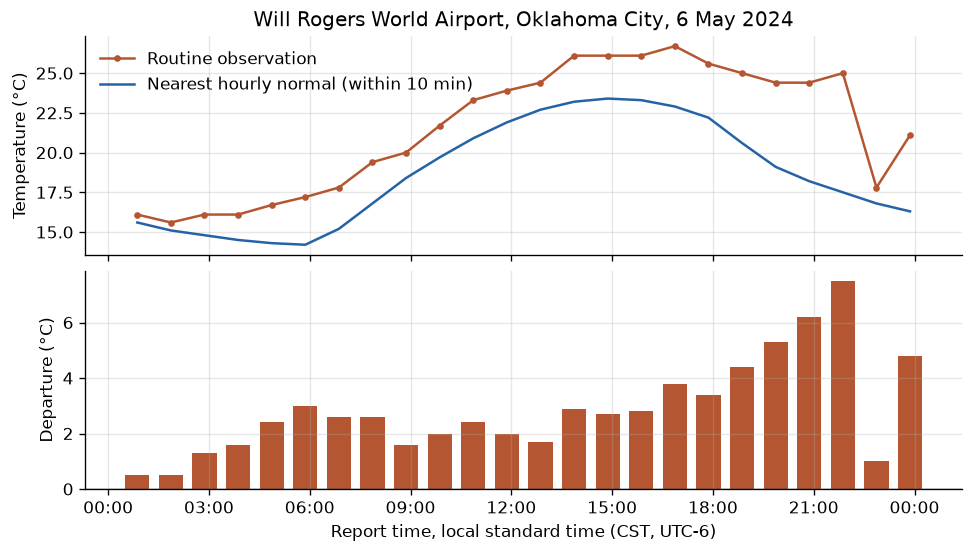

In [5]:
fig, (temps, departures) = plt.subplots(2, 1, sharex=True, layout="constrained")
temps.plot(
    usable["observed_at"],
    usable["observed_c"],
    marker=".",
    color="#b45631",
    label="Routine observation",
)
temps.plot(
    usable["observed_at"],
    usable["normal_c"],
    color="#2563a6",
    label="Nearest hourly normal (within 10 min)",
)
temps.set_ylabel("Temperature (°C)")
temps.set_title("Will Rogers World Airport, Oklahoma City, 6 May 2024")
temps.legend(loc="upper left", frameon=False)
departures.bar(usable["observed_at"], usable["departure_c"], width=0.03, color="#b45631")
departures.axhline(0, color="#444444", linewidth=0.8)
departures.set_ylabel("Departure (°C)")
departures.set_xlabel("Report time, local standard time (CST, UTC-6)")
departures.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.show()

In [6]:
warm = usable["departure_c"].gt(0).sum()
peak = usable.loc[usable["departure_c"].idxmax()]
print(f"{warm} of {len(usable)} usable reports were warmer than the matched normal.")
print(f"Mean departure across matched reports: {usable.departure_c.mean():.2f} C")
print(f"Largest warm departure: {peak.departure_c:.1f} C at {peak.observed_at:%Y-%m-%d %H:%M} CST")
print(
    f"Matched normal: {peak.normal_at:%Y-%m-%d %H:%M} CST ({peak.offset_minutes:.0f} minutes later)"
)

24 of 24 usable reports were warmer than the matched normal.
Mean departure across matched reports: 2.88 C
Largest warm departure: 7.5 C at 2024-05-06 21:52 CST
Matched normal: 2024-05-06 22:00 CST (8 minutes later)


## Pin and cite

`verify` checks the cached bytes against the lockfile. Restoring the same
lockfile into an empty temporary cache and comparing every file proves exact
restoration at the time of execution, not perpetual upstream availability.
NCEI can revise both query responses; keep the manifest, lockfile, and cached
bytes together, and review a later mismatch before accepting an update. The
citations below are what a methods section needs, and
`usdata cite dataset.yaml` prints the same.

In [7]:
assert verify(manifest) == []
with TemporaryDirectory(prefix="usdata-hourly-restore-") as fresh:
    restored = pull(manifest, root=fresh)
    assert restored.from_lockfile
    assert all(not item.from_cache for item in restored.fetched)
    assert restored.lockfile == result.lockfile
    assert verify(manifest, root=fresh) == []
    for name in ("observations", "normals"):
        assert restored.one(name).path.read_bytes() == result.one(name).path.read_bytes()
print("Both inputs restored byte-for-byte into an empty cache and passed verification.")
print()
for citation in cite_lockfile(manifest):
    print(citation.as_text())

Both inputs restored byte-for-byte into an empty cache and passed verification.

noaa:lcd
  NOAA National Centers for Environmental Information, U.S. Local Climatological Data, accessed via usdata
  homepage: https://www.ncei.noaa.gov/products/land-based-station/local-climatological-data
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00684/html
  retrieved: 2026-09-24; 1 checksummed asset (5,256 bytes) pinned by usdata 0.26.0
  sources: observations
noaa:climate-normals
  Palecki, Michael; Durre, Imke; Applequist, Scott; Arguez, Anthony; Lawrimore, Jay (2021). U.S. Climate Normals 2020 (1991-2020). NOAA National Centers for Environmental Information; cite the record for the period used
  homepage: https://www.ncei.noaa.gov/products/land-based-station/us-climate-normals
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/products/land-based-station/us-climate-normals
  ret

## What was awkward

- One airport has different identifiers in LCD and normals. The manifest
  spells out both; no automatic station crosswalk is assumed.
- Local standard time looks like an ordinary timestamp but must not follow
  daylight saving time. The normals also omit the year and February 29.
- Routine observations occur eight minutes before the nearest normal. The
  tolerance is an analysis choice, and the final report needs the next day's
  midnight normal, so the normals request runs a day longer than the
  observations.
- LCD mixes routine, special, synoptic, and summary reports, and quality
  suffixes can make a temperature nonnumeric. The comparison counts excluded
  types and invalid values instead of treating every row as an hourly
  temperature or silently stripping the suffixes.